<a href="https://colab.research.google.com/github/Rafie1715/Sleep-Quality-Monitoring-App-using-Random-Forest/blob/main/Machine_Learning_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 1. BACA DATA CSV (Pastikan nama file sesuai dengan yang di-upload)
file_name = "Kuesioner Kualitas & Kebiasaan Tidur Mahasiswa (Jawaban) - Form Responses 1.csv"
df = pd.read_csv(file_name)

In [ ]:
df.rename(columns={
    df.columns[8]: 'durasi_kategori',
    df.columns[9]: 'latensi',
    df.columns[10]: 'gangguan',
    df.columns[11]: 'kebiasaan',
    df.columns[12]: 'mood',
    df.columns[13]: 'target'
}, inplace=True)

In [ ]:
# Hapus data kosong (jika ada)
df = df.dropna(subset=['target'])

In [ ]:
# 2. DATA PREPROCESSING (Menyamakan dengan variabel di Android SleepRecord.kt)

# A. Konversi Durasi menjadi Angka (Menit)
def get_duration(x):
    if 'Kurang dari 5 Jam' in x: return 240
    elif '5 - 6 Jam' in x: return 330
    elif '6 - 7 Jam' in x: return 390
    elif 'Lebih dari 7 Jam' in x: return 480
    return 360
df['duration_minutes'] = df['durasi_kategori'].astype(str).apply(get_duration)

In [ ]:
# B. Konversi Latensi
def map_latency(x):
    if 'Kurang dari 15' in x: return '<15 menit'
    elif '15 - 30' in x: return '15-30 menit'
    elif '31 - 60' in x: return '30-60 menit'
    elif 'Lebih dari 1 Jam' in x: return '>60 menit'
    return '15-30 menit'
df['sleep_latency'] = df['latensi'].astype(str).apply(map_latency)

In [ ]:
# C. Ekstrak Boolean (1 = Ya, 0 = Tidak) untuk Kebiasaan & Gangguan
df['is_stressed'] = df['kebiasaan'].astype(str).apply(lambda x: 1 if 'pikiran' in x.lower() or 'stres' in x.lower() else 0)
df['has_caffeine'] = df['kebiasaan'].astype(str).apply(lambda x: 1 if 'kopi' in x.lower() or 'kafein' in x.lower() else 0)
df['high_screen_time'] = df['kebiasaan'].astype(str).apply(lambda x: 1 if 'layar' in x.lower() or 'hp' in x.lower() else 0)

df['frequent_awakenings'] = df['gangguan'].astype(str).apply(lambda x: 1 if 'sering terbangun' in x.lower() else 0)
df['bad_temperature'] = df['gangguan'].astype(str).apply(lambda x: 1 if 'fisik lingkungan' in x.lower() or 'suhu' in x.lower() else 0)

In [ ]:
# D. Konversi Mood & Target
def map_mood(x):
    if 'Bugar' in x: return 'Baik'
    elif 'Biasa' in x: return 'Cukup'
    elif 'Lelah' in x: return 'Buruk'
    return 'Cukup'
df['wake_up_mood'] = df['mood'].astype(str).apply(map_mood)

def map_target(x):
    if 'Baik' in x: return 'Baik'
    elif 'Cukup' in x: return 'Cukup'
    elif 'Buruk' in x: return 'Buruk'
    return 'Cukup'
df['sleep_quality'] = df['target'].astype(str).apply(map_target)

In [ ]:
# 3. PENYUSUNAN FITUR (X) DAN TARGET (y)
X_numeric = df[['duration_minutes', 'is_stressed', 'has_caffeine', 'high_screen_time', 'frequent_awakenings', 'bad_temperature']]
# One-Hot Encoding untuk data teks
lat_dummies = pd.get_dummies(df['sleep_latency'], prefix='latensi')
mood_dummies = pd.get_dummies(df['wake_up_mood'], prefix='mood')

In [ ]:
# Gabungkan semua fitur
X = pd.concat([X_numeric, lat_dummies, mood_dummies], axis=1)
y = df['sleep_quality']

In [ ]:
# Ubah Target (Baik, Cukup, Buruk) menjadi angka (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# 4. PEMBAGIAN DATA & PELATIHAN MODEL
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=12)

print("\n" + "="*50)
print(" SKENARIO 1: TANPA PENANGANAN (BASELINE) ")
print("="*50)
# Model tanpa class_weight
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
akurasi_base = accuracy_score(y_test, y_pred_base) * 100
print(f"Akurasi Baseline: {akurasi_base:.2f}%")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))


 SKENARIO 1: TANPA PENANGANAN (BASELINE) 
Akurasi Baseline: 93.65%
              precision    recall  f1-score   support

        Baik       1.00      1.00      1.00        11
       Buruk       0.94      0.83      0.88        18
       Cukup       0.92      0.97      0.94        34

    accuracy                           0.94        63
   macro avg       0.95      0.93      0.94        63
weighted avg       0.94      0.94      0.94        63



In [ ]:
print("\n" + "="*50)
print(" SKENARIO 2: DENGAN CLASS WEIGHT='BALANCED' ")
print("="*50)
# Model optimal dengan class_weight
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_opt = rf_model.predict(X_test)
akurasi_opt = accuracy_score(y_test, y_pred_opt) * 100
print(f"Akurasi Optimal: {akurasi_opt:.2f}%")
print(classification_report(y_test, y_pred_opt, target_names=le.classes_))


 SKENARIO 2: DENGAN CLASS WEIGHT='BALANCED' 
Akurasi Optimal: 92.06%
              precision    recall  f1-score   support

        Baik       0.85      1.00      0.92        11
       Buruk       0.89      0.94      0.92        18
       Cukup       0.97      0.88      0.92        34

    accuracy                           0.92        63
   macro avg       0.90      0.94      0.92        63
weighted avg       0.93      0.92      0.92        63



In [ ]:
# 5. EVALUASI MODEL
y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred) * 100

print("="*50)
print(f"AKURASI MODEL RANDOM FOREST: {akurasi:.2f}%")
print("="*50)
print("\n[ CLASSIFICATION REPORT ]")
print(classification_report(y_test, y_pred, target_names=le.classes_))

AKURASI MODEL RANDOM FOREST: 92.06%

[ CLASSIFICATION REPORT ]
              precision    recall  f1-score   support

        Baik       0.85      1.00      0.92        11
       Buruk       0.89      0.94      0.92        18
       Cukup       0.97      0.88      0.92        34

    accuracy                           0.92        63
   macro avg       0.90      0.94      0.92        63
weighted avg       0.93      0.92      0.92        63



/tmp/ipykernel_963/2213920008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sleep_quality', palette='Set2', order=['Baik', 'Cukup', 'Buruk'])


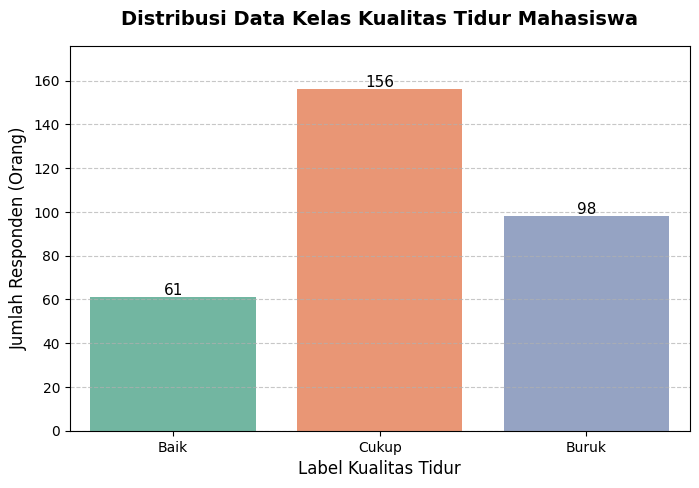

In [ ]:
# GRAFIK 1: DISTRIBUSI KELAS KUALITAS TIDUR (TARGET)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Menggunakan kolom 'sleep_quality' agar labelnya pendek dan rapi
sns.countplot(data=df, x='sleep_quality', palette='Set2', order=['Baik', 'Cukup', 'Buruk'])

plt.title('Distribusi Data Kelas Kualitas Tidur Mahasiswa', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Label Kualitas Tidur', fontsize=12)
plt.ylabel('Jumlah Responden (Orang)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan angka jumlah di atas setiap bar (opsional agar lebih keren)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, df['sleep_quality'].value_counts().max() + 20) # Memberi ruang di atas bar
plt.show()

/tmp/ipykernel_963/2110216181.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=df_importance, palette='viridis')


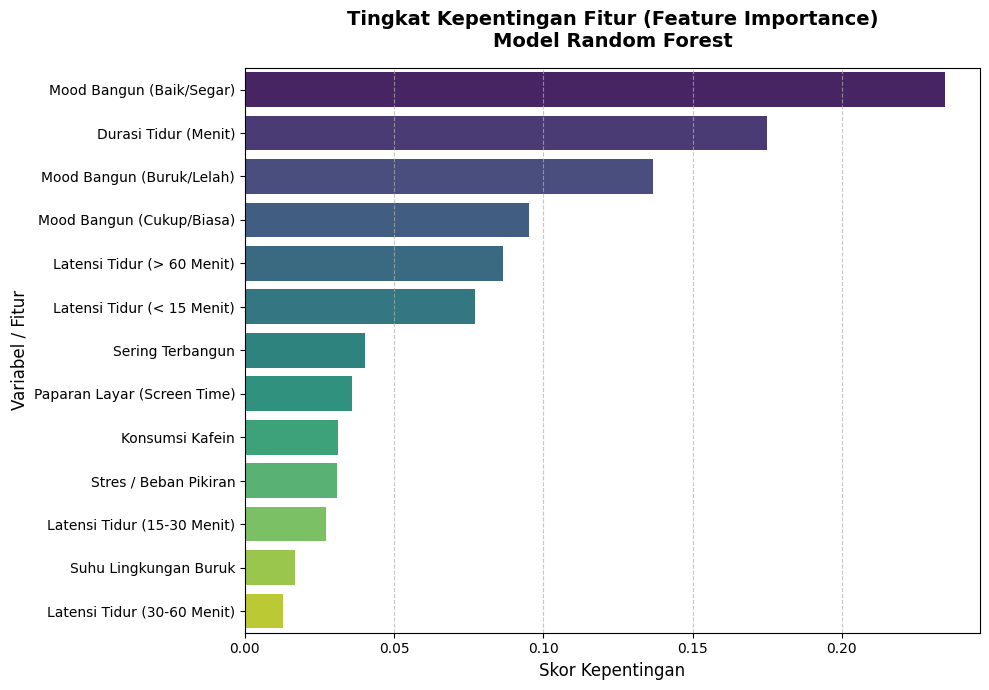

In [ ]:
# GRAFIK 2: FEATURE IMPORTANCE (TINGKAT KEPENTINGAN FITUR)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Kamus terjemahan fitur agar rapi di laporan skripsi
feature_mapping = {
    'duration_minutes': 'Durasi Tidur (Menit)',
    'is_stressed': 'Stres / Beban Pikiran',
    'has_caffeine': 'Konsumsi Kafein',
    'high_screen_time': 'Paparan Layar (Screen Time)',
    'frequent_awakenings': 'Sering Terbangun',
    'bad_temperature': 'Suhu Lingkungan Buruk',
    'latensi_15-30 menit': 'Latensi Tidur (15-30 Menit)',
    'latensi_30-60 menit': 'Latensi Tidur (30-60 Menit)',
    'latensi_<15 menit': 'Latensi Tidur (< 15 Menit)',
    'latensi_>60 menit': 'Latensi Tidur (> 60 Menit)',
    'mood_Baik': 'Mood Bangun (Baik/Segar)',
    'mood_Buruk': 'Mood Bangun (Buruk/Lelah)',
    'mood_Cukup': 'Mood Bangun (Cukup/Biasa)'
}

# Mengambil nilai feature importance dari model rf_model
importances = rf_model.feature_importances_
feature_names = X.columns
clean_feature_names = [feature_mapping.get(col, col) for col in feature_names]

# Membuat DataFrame
df_importance = pd.DataFrame({'Fitur': clean_feature_names, 'Tingkat Kepentingan': importances})
df_importance = df_importance.sort_values(by='Tingkat Kepentingan', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 7)) # Diperbesar agar tulisan tidak berdempetan
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=df_importance, palette='viridis')

plt.title('Tingkat Kepentingan Fitur (Feature Importance)\nModel Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skor Kepentingan', fontsize=12)
plt.ylabel('Variabel / Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

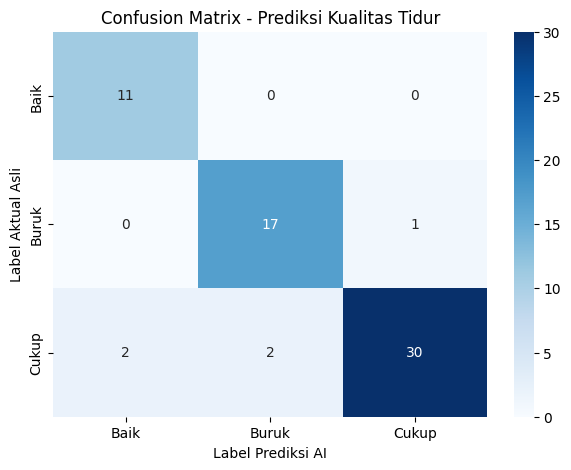

In [ ]:
# 6. VISUALISASI CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Prediksi Kualitas Tidur')
plt.ylabel('Label Aktual Asli')
plt.xlabel('Label Prediksi AI')
plt.show()

In [ ]:
# 1. Install library M2CGEN
!pip install m2cgen

import m2cgen as m2c

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 3.3 MB/s eta 0:00:00


In [ ]:
# 2. Ubah model Random Forest (rf_model) menjadi bahasa Java
# Kita beri nama class-nya "SleepQualityClassifier"
code = m2c.export_to_java(rf_model, class_name="SleepQualityClassifier")

# 3. Simpan kodenya menjadi file .java
with open("SleepQualityClassifier.java", "w") as text_file:
    text_file.write(code)

print("Berhasil! File SleepQualityClassifier.java sudah dibuat.")
print("Silakan klik logo Folder di sebelah kiri Colab untuk mengunduhnya.")

Berhasil! File SleepQualityClassifier.java sudah dibuat.
Silakan klik logo Folder di sebelah kiri Colab untuk mengunduhnya.


In [ ]:
# Menampilkan urutan fitur (SANGAT PENTING untuk Android nanti)
print("\nURUTAN INPUT ARRAY DI ANDROID HARUS SEPERTI INI:")
for i, col in enumerate(X.columns):
    print(f"Index {i}: {col}")


URUTAN INPUT ARRAY DI ANDROID HARUS SEPERTI INI:
Index 0: duration_minutes
Index 1: is_stressed
Index 2: has_caffeine
Index 3: high_screen_time
Index 4: frequent_awakenings
Index 5: bad_temperature
Index 6: latensi_15-30 menit
Index 7: latensi_30-60 menit
Index 8: latensi_<15 menit
Index 9: latensi_>60 menit
Index 10: mood_Baik
Index 11: mood_Buruk
Index 12: mood_Cukup
